In [2]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score as accuracy_score_sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

In [3]:
# source = https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
file_url = "https://raw.githubusercontent.com/Tobbs11/Diabetes-readmission-Project/main/diabetic_data.csv"
diabetes_df = pd.read_csv(file_url)

In [4]:
diabetes_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [5]:
diabetes_df.shape, diabetes_df.columns

((101766, 50),
 Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
        'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
        'time_in_hospital', 'payer_code', 'medical_specialty',
        'num_lab_procedures', 'num_procedures', 'num_medications',
        'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
        'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
        'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
        'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
        'tolazamide', 'examide', 'citoglipton', 'insulin',
        'glyburide-metformin', 'glipizide-metformin',
        'glimepiride-pioglitazone', 'metformin-rosiglitazone',
        'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
       dtype='object'))

## Data Cleaning and Preprocessing

In [6]:
# drop highly missing and irrelevant columns
columns_to_drop = ['weight', 'medical_specialty', 'max_glu_serum']
diabetes_df.drop(columns=columns_to_drop, inplace=True)

In [7]:
# Replace missing values
diabetes_df.replace('?', np.nan, inplace=True)
diabetes_df['race'].fillna('Other', inplace=True)

In [8]:
admission_type_id = { 
    1 : 'Emergency',
    2 : 'Urgent',
    3 : 'Elective',
    4 : 'Newborn',
    5 : 'Not Available',
    6 : 'NULL',
    7 : 'Trauma Center',
    8 : 'Not Mapped' 
}

In [9]:
discharge_disposition_id = { 
    1 : 'Discharged to home',
    2 : 'Discharged/transferred to another short term hospital',
    3 : 'Discharged/transferred to SNF',
    4 : 'Discharged/transferred to ICF',
    5 : 'Discharged/transferred to another type of inpatient care institution',
    6 : 'Discharged/transferred to home with home health service',
    7 : 'Left AMA', 
    8 : 'Discharged/transferred to home under care of Home IV provider', 
    9 : 'Admitted as an inpatient to this hospital', 
    10 : 'Neonate discharged to another hospital for neonatal aftercare',
    11 : 'Expired',
    12 : 'Still patient or expected to return for outpatient services',
    13 : 'Hospice / home',
    14 : 'Hospice / medical facility',
    15 : 'Discharged/transferred within this institution to Medicare approved swing bed',
    16 : 'Discharged/transferred/referred another institution for outpatient services', 
    17 : 'Discharged/transferred/referred to this institution for outpatient services',
    18 : 'NULL',
    19 : 'Expired at home. Medicaid only, hospice',
    20 : 'Expired in a medical facility. Medicaid only, hospice',
    21 : 'Expired, place unknown. Medicaid only, hospice',
    22 : 'Discharged/transferred to another rehab fac including rehab units of a hospital',
    23 : 'Discharged/transferred to a long term care hospital',
    24 : 'Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare',
    25 : 'Not Mapped',
    26 : 'Unknown/Invalid',
    27 : 'Discharged/transferred to a federal health care facility',
    28 : 'Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital',
    29 : 'Discharged/transferred to a Critical Access Hospital (CAH)' ,
    30 : 'Discharged/transferred to another Type of Health Care Institution not Defined Elsewhere',
}

In [10]:
admission_source_id = { 
    1 : 'Physician Referral', 
    2 : 'Clinic Referral', 
    3 : 'HMO Referral',
    4 : 'Transfer from a hospital',
    5 : 'Transfer from a Skilled Nursing Facility (SNF)', 
    6 : 'Transfer from another health care facility',
    7 : 'Emergency Room',
    8 : 'Court/Law Enforcement',
    9 :  'Not Available',
    10 : 'Transfer from critial access hospital',
    11 : 'Normal Delivery', 12 : 'Premature Delivery', 13 : 'Sick Baby', 14 : 'Extramural Birth',
    15 : 'Not Available', 17 : 'NULL', 18 : 'Transfer From Another Home Health Agency',
    19 : 'Readmission to Same Home Health Agency', 20 : 'Not Mapped', 21 : 'Unknown/Invalid',
    22 : 'Transfer from hospital inpt/same fac reslt in a sep claim',
    23 : 'Born inside this hospital', 24 : 'Born outside this hospital',
    25 : 'Transfer from Ambulatory Surgery Center',
    26 : 'Transfer from Hospice'
}

In [11]:
import math

def map_icd9(code):
    """
    ICD9 diagnosis codes
    https://onlinelibrary.wiley.com/doi/10.1155/2014/781670
    """
    try:
        code = float(code)
    except:
        return 'Unknown'
    if math.isnan(code):
        return 'Unknown'
    elif (390 <= code <= 459) or (code == 785):
        return 'Circulatory'
    elif (460 <= code <= 519) or (code == 786):
        return 'Respiratory'
    elif (520 <= code <= 579) or (code == 787):
        return 'Digestive'
    elif int(code) == 250:
        return 'Diabetes'
    elif 800 <= code <= 999:
        return 'Injury'
    elif 710 <= code <= 739:
        return 'Musculoskeletal'
    elif 580 <= code <= 629:
        return 'Genitourinary'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    elif 290 <= code <= 319:
        return 'MentalDisorders'
    else:
        return 'Other'

In [12]:
diabetes_df['expiration_ind'] = diabetes_df['discharge_disposition_id'].isin([11,13,14,19,20,21]).astype('int')
diabetes_df['MP_DM_payer_ind'] = ((diabetes_df['payer_code'] == 'MP') | 
                               (diabetes_df['payer_code'] == 'DM')).astype(int)

# Apply mapping 
for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetes_df[col] = diabetes_df[col].apply(map_icd9)
    
diabetes_df['admission_type'] = diabetes_df['admission_type_id'].map(admission_type_id)
diabetes_df['discharge_disposition'] = diabetes_df['discharge_disposition_id'].map(discharge_disposition_id)
diabetes_df['admission_source'] = diabetes_df['admission_source_id'].map(admission_source_id)

In [13]:
diabetes_df['admission_grp_1_ind'] = ( diabetes_df['admission_type'].isin(['NULL','Emergency'])).astype(int)
diabetes_df['admission_grp_2_ind'] = ( diabetes_df['admission_type'].isin(['Elective','Not Mapped'])).astype(int)

diabetes_df['discharge_grp_1_ind'] = ( diabetes_df['discharge_disposition'].isin(['Discharged/transferred to a long term care hospital'
                                                                           ,'NULL'
                                                                           ,'Discharged to home'])).astype(int)

diabetes_df['discharge_grp_2_ind'] = ( diabetes_df['discharge_disposition'].isin(['Left AMA'
                                                                            ,'Discharged/transferred to another type of inpatient care institution'
                                                                            ,'Discharged/transferred to SNF'
                                                                            ,'Discharged/transferred to home with home health service'
                                                                            ,'Discharged/transferred to another rehab fac including rehab units of a hospital'])).astype(int)

diabetes_df['admission_type_ind'] = ( diabetes_df['admission_source'].isin(['Clinic Referral'
                                                                     ,'Transfer from a hospital'
                                                                     ,'Transfer from another health care facility'])).astype(int)

diabetes_df['mb_admission_grp_1_ct'] = diabetes_df.groupby('patient_nbr')['admission_grp_1_ind'].transform('sum')
diabetes_df['mb_admission_grp_2_ct'] = diabetes_df.groupby('patient_nbr')['admission_grp_2_ind'].transform('sum')
diabetes_df['mb_discharge_grp_1_ct'] = diabetes_df.groupby('patient_nbr')['discharge_grp_1_ind'].transform('sum')
diabetes_df['mb_discharge_grp_2_ct'] = diabetes_df.groupby('patient_nbr')['discharge_grp_2_ind'].transform('sum')
diabetes_df['mb_admission_type_ct']  = diabetes_df.groupby('patient_nbr')['admission_type_ind'].transform('sum')
drop = []
drop.extend(['payer_code', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id'])
drop.extend(['admission_grp_1_ind','admission_grp_2_ind','discharge_grp_1_ind', 'discharge_grp_2_ind','admission_type_ind'])

In [14]:
#clean dx codes and replace missing values 
diabetes_df['diag_1'] = diabetes_df['diag_1'].astype(str).str[ :3]
diabetes_df['diag_2'] = diabetes_df['diag_2'].astype(str).str[ :3]
diabetes_df['diag_3'] = diabetes_df['diag_3'].astype(str).str[ :3]

diabetes_df['diag_1'] = diabetes_df['diag_1'].replace('?', 'No diag')
diabetes_df['diag_2'] = diabetes_df['diag_2'].replace('?', 'No diag')
diabetes_df['diag_3'] = diabetes_df['diag_3'].replace('?', 'No diag')

In [15]:
#add patient-level count of unique diagnoses codes 
# Melt the dataset to have all diagnoses in a single column
diagnosis_melted = diabetes_df.melt(id_vars=['patient_nbr'], value_vars=['diag_1', 'diag_2', 'diag_3'])

# Group by patient_nbr and count distinct diagnosis codes
distinct_counts = diagnosis_melted.groupby('patient_nbr')['value'].nunique().reset_index()

# Rename columns for clarity
distinct_counts.columns = ['patient_nbr', 'distinct_diag_count']

diabetes_df = diabetes_df.merge(distinct_counts, on='patient_nbr', how='left')

del diagnosis_melted, distinct_counts

In [16]:

diabetes_df['diag_1_freq'] = diabetes_df.groupby('diag_1')['diag_1'].transform('count')
diabetes_df['diag_2_freq'] = diabetes_df.groupby('diag_2')['diag_2'].transform('count')
diabetes_df['diag_3_freq'] = diabetes_df.groupby('diag_3')['diag_3'].transform('count')


# # Major ordered drivers of readmission
diabetes_df['diag_1_428_ind'] = ( diabetes_df['diag_1']=='428' ).astype(int) #CHF NOS
diabetes_df['diag_1_491_ind'] = ( diabetes_df['diag_1']=='491' ).astype(int) #SIMPLE CHR BRONCHITIS
diabetes_df['diag_1_493_ind'] = ( diabetes_df['diag_1']=='493' ).astype(int) #EXTRINSIC ASTHMA NOS

diabetes_df['diag_2_403_ind'] = ( diabetes_df['diag_2']=='403' ).astype(int) #MAL HY KID W CR KID I-IV
diabetes_df['diag_2_707_ind'] = ( diabetes_df['diag_2']=='707' ).astype(int) #DECUBITUS ULCER
diabetes_df['diag_2_585_ind'] = ( diabetes_df['diag_2']=='585' ).astype(int) #CHRONIC RENAL FAILURE
diabetes_df['diag_2_491_ind'] = ( diabetes_df['diag_2']=='491' ).astype(int) #SIMPLE CHR BRONCHITIS

diabetes_df['diag_3_403_ind'] = ( diabetes_df['diag_3']=='403' ).astype(int) #MAL HY KID W CR KID I-IV
diabetes_df['diag_3_585_ind'] = ( diabetes_df['diag_3']=='585' ).astype(int) #CHRONIC RENAL FAILURE
diabetes_df['diag_3_707_ind'] = ( diabetes_df['diag_3']=='707' ).astype(int) #DECUBITUS ULCER


In [17]:
# further preprocessing

diabetes_df['diag_1_driver_ind'] = diabetes_df['diag_1'].isin([ '403' #MAL HY KID W CR KID I-IV
, '787' #NAUSEA WITH VOMITING
, '404' #MAL HY HT/KD I-IV W/O HF
, '707' #DECUBITUS ULCER
, '572' #ABSCESS OF LIVER
, '730' #AC OSTEOMYELITIS-UNSPEC
, 'V58' #RADIOTHERAPY ENCOUNTER
, '537' #ACQ PYLORIC STENOSIS
, '443' #RAYNAUD'S SYNDROME
, '292' #DRUG WITHDRAWAL
, '496' #CHR AIRWAY OBSTRUCT NEC
, '585' #CHRONIC RENAL FAILURE
, '282' #HEREDITARY SPHEROCYTOSIS
, '799' #ASPHYXIA
, '284' #CONGEN APLASTIC ANEMIA
, '567' #PERITONITIS IN INFEC DIS
, '293' #DELIRIUM D/T OTHER COND
, '924' #CONTUSION OF THIGH
, '340' #MULTIPLE SCLEROSIS
, '514' #PULM CONGEST/HYPOSTASIS
, '485' #BRONCHOPNEUMONIA ORG NOS
, '714' #RHEUMATOID ARTHRITIS
, '277' #CYSTIC FIBROS W/O ILEUS
, '150' #MAL NEO CERVICAL ESOPHAG
, '135' #SARCOIDOSIS
, '522']).astype(int) #PULPITIS

diabetes_df['diag_2_driver_ind'] = diabetes_df['diag_2'].isin([ '571' #ALCOHOLIC FATTY LIVER
, '404' #MAL HY HT/KD I-IV W/O HF
, '536' #ACHLORHYDRIA
, '202' #NDLR LYM UNSP XTRNDL ORG
, '396' #MITRAL/AORTIC STENOSIS
, '304' #OPIOID DEPENDENCE-UNSPEC
, '444' #ABD AORTIC EMBOLISM
, '581' #NEPHROTIC SYN, PROLIFER
, '731' #OSTEITIS DEFORMANS NOS
, 'E94' #ADV EFF ANALEPTICS
, '397' #TRICUSPID VALVE DISEASE
, '595' #ACUTE CYSTITIS
, '205' #AC MYL LEUK WO ACHV RMSN
, '490' #BRONCHITIS NOS
, '459' #HEMORRHAGE NOS
, '189' #MALIG NEOPL KIDNEY
, '154' #MAL NEO RECTOSIGMOID JCT
, '332' #PARALYSIS AGITANS
, 'V49' #DEFICIENCIES OF LIMBS
, '681' #CELLULITIS, FINGER NOS
, '150' #MAL NEO CERVICAL ESOPHAG
, '537' #ACQ PYLORIC STENOSIS
, '094' ]).astype(int) #TABES DORSALIS

diabetes_df['diag_3_driver_ind'] = diabetes_df['diag_3'].isin([  '682' #CELLULITIS OF FACE
, '070' #HEPATITIS A WITH COMA
, '536' #ACHLORHYDRIA
, 'V42' #KIDNEY TRANSPLANT STATUS
, '443' #RAYNAUD'S SYNDROME
, '304' #OPIOID DEPENDENCE-UNSPEC
, '284' #CONGEN APLASTIC ANEMIA
, '466' #ACUTE BRONCHITIS
, '459' #HEMORRHAGE NOS
, '581' #NEPHROTIC SYN, PROLIFER
, '337' #IDIOPATH AUTO NEUROPATHY
, '583' #PROLIFERAT NEPHRITIS NOS
, '203' #MULT MYE W/O ACHV RMSON
, 'V46' #DEPENDENCE ON ASPIRATOR
, '482' #K. PNEUMONIAE PNEUMONIA
, 'V49' #DEFICIENCIES OF LIMBS
, '444' #ABD AORTIC EMBOLISM
, '174' #MALIG NEO NIPPLE
, '456' #ESOPHAG VARICES W BLEED
, '519' #TRACHEOSTOMY COMP NOS
, 'E92' #ACC-POWERED LAWN MOWER
, 'V62' #UNEMPLOYMENT
, '356' #HERED PERIPH NEUROPATHY
, '711' #PYOGEN ARTHRITIS-UNSPEC
, '053' ]).astype(int)  #HERPES ZOSTER MENINGITIS

diabetes_df['diagnosis_array'] = diabetes_df[['diag_1', 'diag_2', 'diag_3']].values.tolist()

# Sort 'diagnosis_array'
diabetes_df['diagnosis_array'] = diabetes_df['diagnosis_array'].apply(sorted)

# Convert list to tuple (to make it hashable for groupby)
diabetes_df['diagnosis_array_tuple'] = diabetes_df['diagnosis_array'].apply(tuple)

# Count frequency of 'diagnosis_array'
diabetes_df['diagnosis_tuple_freq'] = diabetes_df.groupby('diagnosis_array_tuple')['diagnosis_array_tuple'].transform('count')

# Assign sorted elements back to new columns (Simplifies frequency analysis)
diabetes_df[['diag_1_sort', 'diag_2_sort', 'diag_3_sort']] = pd.DataFrame(diabetes_df['diagnosis_array'].tolist(), index=diabetes_df.index)

diabetes_df['diag_1_sort_freq'] = diabetes_df.groupby('diag_1_sort')['diag_1_sort'].transform('count')
diabetes_df['diag_2_sort_freq'] = diabetes_df.groupby('diag_2_sort')['diag_2_sort'].transform('count')
diabetes_df['diag_3_sort_freq'] = diabetes_df.groupby('diag_3_sort')['diag_3_sort'].transform('count')

# Drop temporary tuple
diabetes_df.drop(columns=['diagnosis_array_tuple'], inplace=True)

# Reformat the array as a tuple-like string
diabetes_df['diagnosis_tuple'] = diabetes_df['diagnosis_array'].apply(lambda x: f"({' '.join(x)})")

# Drop temporary array
diabetes_df.drop(columns=['diagnosis_array'], inplace=True)
                                          
diabetes_df['high propensity tuple ind'] = diabetes_df['diagnosis_tuple'].isin(['(250 403 428)'
, '(250 428 585)'
, '(250 276 536)'
, '(250 428 491)'
, '(276 403 585)'
, '(250 276 428)'
, '(250 276 403)'
, '(424 427 428)'
, '(250 403 996)'
, '(250 428 496)'
, '(250 425 428)'
, '(403 428 584)'
, '(427 428 491)'
, '(250 428 707)'
, '(250 682 707)'
, '(428 486 496)'
, '(428 491 518)'
, '(250 276 577)'
, '(427 428 496)'
, '(425 427 428)'
, '(414 428 496)'
, '(427 428 599)'
, '(250 403 585)'
, '(427 427 428)'
, '(428 486 491)'
, '(401 414 428)'
, '(276 428 584)'
, '(427 428 428)'
, '(403 428 585)'
, '(250 440 707)'
, '(250 707 730)'
, '(486 491 518)'
, '(250 401 428)'
, '(427 428 486)'
, '(411 414 496)'
, '(250 414 428)'
, '(250 401 493)'
, '(250 276 558)'
, '(250 730 731)'
, '(276 38 599)'
, '(250 428 486)'
, '(250 401 491)'
, '(250 427 428)'
, '(250 276 599)'
, '(276 427 428)'
, '(250 707 785)'
, '(411 414 428)'
, '(403 585 996)']).astype(int)

dx_list=[ '428'
, '403'
, '707'
, '585'
, '491'
, '396'
, '440'
, '453'
, '571'
, '284'
, '304'
, '482'
, '150'
, '282'
, '332'
, '443'
, '719'
, '423'
, '281'
, '536'
, '368'
, '515'
, '595'
, '572'
, '681'
, '581'
, '537'
, '490'
, '583'
, 'V46'
, '519'
, '300'
, '567'
, 'E92'
, 'V49'
, '094'
, '514'
, '494'
, '042'
, '404'
, '346'
, '792'
, '398'
, '753'
, '577'
, '730'
, '444'
, '459'
, '790'
, '337'
, '397'
, '292'
, 'V42'
, '289']


# Create dx_events with the selected columns
dx_events = diabetes_df[['patient_nbr', 'encounter_id', 'diag_1', 'diag_2', 'diag_3']].copy(deep=True)

# Add new empty columns for each element in dx_list
for dx in dx_list:
    dx_events[f'dx_{dx}_ind'] = pd.NA  # Creates empty columns with missing values (best for Pandas)

# populate each column
for dx in dx_list:
    dx_events[f'dx_{dx}_ind'] = ((dx_events['diag_1'] == dx) |
                                 (dx_events['diag_2'] == dx) |
                                 (dx_events['diag_3'] == dx) ).astype(int)
# Group by patient_nbr and compute max and sum for each diagnosis indicator
dx_aggregated = dx_events.groupby('patient_nbr').agg(
    {f'dx_{dx}_ind': ['max', 'sum'] for dx in dx_list}
)

# Rename columns to match SQL-style naming
dx_aggregated.columns = [f'{col[0]}_{col[1]}' for col in dx_aggregated.columns]

# Reset index to bring patient_nbr back as a column
dx_aggregated = dx_aggregated.reset_index()

del dx_events

diabetes_df = diabetes_df.merge(dx_aggregated, on='patient_nbr', how='left')

del dx_aggregated

In [18]:
# patient-level features

diabetes_df['readmitted_lt30_ind'] = ( diabetes_df['readmitted']=='<30' ).astype(int)
diabetes_df['readmitted_gt30_ind'] = ( diabetes_df['readmitted']=='>30' ).astype(int)
diabetes_df['readmitted_no_ind'] = ( diabetes_df['readmitted']=='NO' ).astype(int)

diabetes_df['encounter_ct'] = diabetes_df['patient_nbr'].map(diabetes_df.groupby('patient_nbr')['encounter_id'].nunique())
diabetes_df['mb_time_in_hospital'] = diabetes_df.groupby('patient_nbr')['time_in_hospital'].transform('sum')
diabetes_df['mb_readmitted_lt30_ct'] = diabetes_df.groupby('patient_nbr')['readmitted_lt30_ind'].transform('sum')
diabetes_df['mb_readmitted_gt30_ct'] = diabetes_df.groupby('patient_nbr')['readmitted_gt30_ind'].transform('sum')
diabetes_df['mb_readmitted_no_ct'] = diabetes_df.groupby('patient_nbr')['readmitted_no_ind'].transform('sum')
diabetes_df['mb_num_lab_procedures_ct'] = diabetes_df.groupby('patient_nbr')['num_lab_procedures'].transform('sum')
diabetes_df['mb_num_procedures_ct'] = diabetes_df.groupby('patient_nbr')['num_procedures'].transform('sum')
diabetes_df['mb_num_medications_ct'] = diabetes_df.groupby('patient_nbr')['num_medications'].transform('sum')
diabetes_df['mb_number_outpatient_ct'] = diabetes_df.groupby('patient_nbr')['number_outpatient'].transform('sum')
diabetes_df['mb_number_emergency_ct'] = diabetes_df.groupby('patient_nbr')['number_emergency'].transform('sum')
diabetes_df['mb_number_inpatient_ct'] = diabetes_df.groupby('patient_nbr')['number_inpatient'].transform('sum')
diabetes_df['mb_number_diagnoses_ct'] = diabetes_df.groupby('patient_nbr')['number_diagnoses'].transform('sum')

drop.extend(['readmitted_lt30_ind', 'readmitted_gt30_ind', 'readmitted_no_ind'])

In [19]:
# Simplify A1C result to binary (hba1c measured or not)
diabetes_df['hba1c_measured'] = diabetes_df['A1Cresult'].apply(lambda x: 0 if x == 'None' else 1)

In [20]:
# Since we are primarily interested in readmission (early or not), 
# we define the readmission attribute (outcome) as binary:
# 1, if the patient was readmitted < or > 30 days of discharge or
# 0, no readmission at all.
diabetes_df['readmitted_binary'] = diabetes_df['readmitted'].apply(lambda x: 0 if x ==
                                                                   'NO' else 1)


In [21]:
# drop redefined columns
drop.extend(['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'A1Cresult', 'readmitted'])

drop.extend([ 'citoglipton'
, 'examide'
, 'acetohexamide'
, 'glimepiride-pioglitazone'
, 'metformin-pioglitazone'
, 'metformin-rosiglitazone'
, 'troglitazone'
, 'glipizide-metformin'
, 'tolbutamide'
, 'miglitol'
, 'tolazamide'
, 'chlorpropamide'
, 'acarbose'
, 'nateglinide'
, 'glyburide-metformin'
, 'repaglinide' ])

diabetes_df.drop(
    columns=drop, 
    inplace=True
)

In [22]:
diabetes_df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient',
       ...
       'mb_readmitted_no_ct', 'mb_num_lab_procedures_ct',
       'mb_num_procedures_ct', 'mb_num_medications_ct',
       'mb_number_outpatient_ct', 'mb_number_emergency_ct',
       'mb_number_inpatient_ct', 'mb_number_diagnoses_ct', 'hba1c_measured',
       'readmitted_binary'],
      dtype='object', length=183)

### Random Forest Classifier

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# check for int32, int64, and float
X = diabetes_df.drop(['readmitted_binary'], axis=1)
y = diabetes_df['readmitted_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numerical_features = [col for col in X.columns if  X[col].dtype.kind in 'iuf']
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=True, handle_unknown='ignore'), categorical_features)
    ]
)

In [25]:
# Evaluate
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Fit
pipeline.fit(X_train, y_train)
print("Done training, predicting..")

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob)
rf_auc = roc_auc_score(y_test, y_prob)

print(classification_report(y_test, y_pred))
print("AUC:", rf_auc)

Done training, predicting..
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     10952
           1       0.90      0.99      0.94      9402

    accuracy                           0.95     20354
   macro avg       0.95      0.95      0.95     20354
weighted avg       0.95      0.95      0.95     20354

AUC: 0.9880812653276606


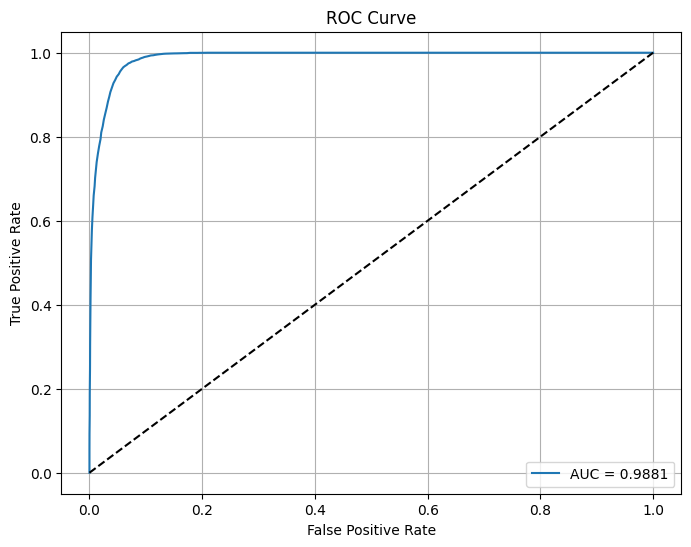

In [26]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(rf_fpr, rf_tpr, label=f"AUC = {rf_auc:.4f}")  # 4 decimal places
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

Confusion Matrix:
 [[9969  983]
 [ 132 9270]]


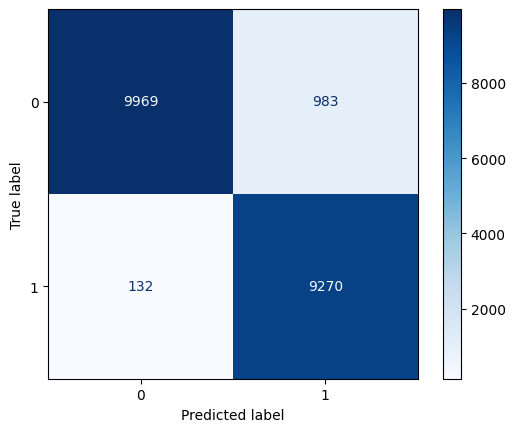

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

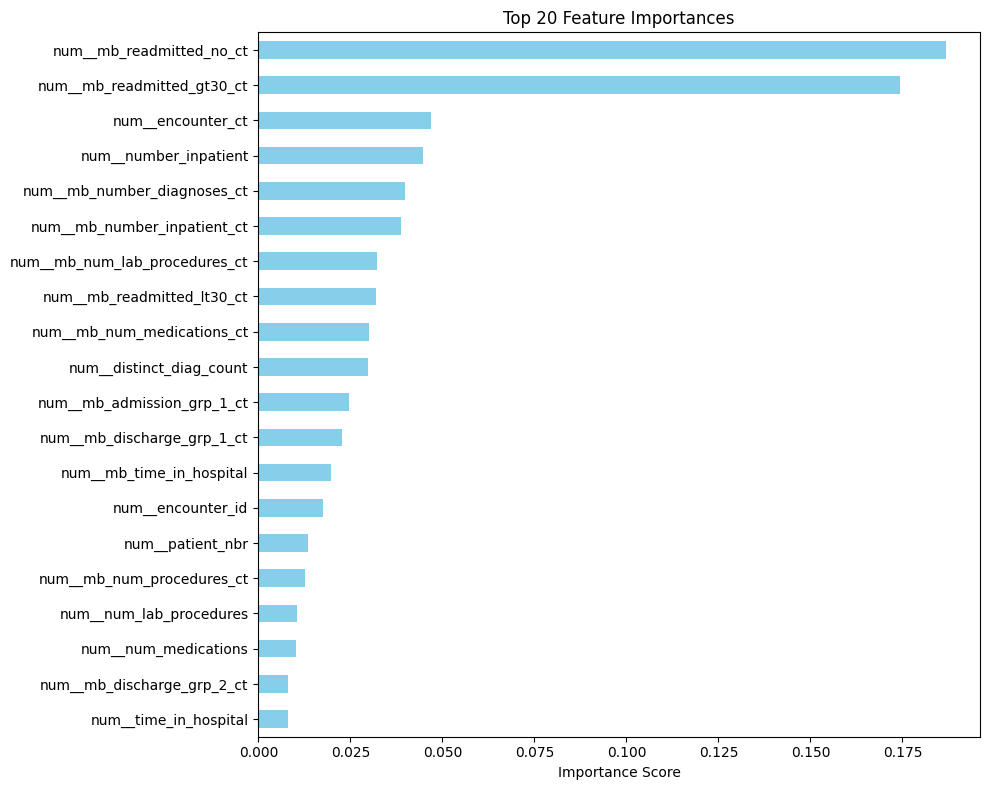

In [28]:
importances = pipeline.named_steps['classifier'].feature_importances_
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Top 20 features
feat_imp.head(20).plot(kind='barh', figsize=(10, 8), color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

## XGBoost

In [29]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

In [30]:
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],  # Number of boosting rounds
    'learning_rate': np.logspace(-3, 0, 10),  # Learning rate (log scale)
    'max_depth': [3, 5, 7, 10],  # Tree depth
    'min_child_weight': [1, 3, 5, 7],  # Minimum sum of instance weight (regularization)
    'gamma': np.linspace(0, 0.5, 5),  # Minimum loss reduction
    'subsample': np.linspace(0.5, 1, 5),  # Fraction of samples per tree
    'colsample_bytree': np.linspace(0.5, 1, 5),  # Fraction of features per tree
    'reg_lambda': np.logspace(-3, 3, 10),  # L2 regularization (Ridge)
    'reg_alpha': np.logspace(-3, 3, 10)  # L1 regularization (Lasso)
}

xgb = XGBClassifier(eval_metric='logloss', random_state=42)

# Set up RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,  # Number of different random combinations to try
    scoring='accuracy',  # Use 'roc_auc' for imbalanced data
    cv=5,  # 5-fold cross-validation
    verbose=1,
    random_state=43,
    n_jobs=-1  # Use all available processors
)


xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', random_search_xgb)
])

# Train
xgb_pipeline.fit(X_train, y_train)

y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_prob_xgb)
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
print(classification_report(y_test, y_pred_xgb))
print("AUC:", xgb_auc)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     10952
           1       0.97      0.98      0.98      9402

    accuracy                           0.98     20354
   macro avg       0.98      0.98      0.98     20354
weighted avg       0.98      0.98      0.98     20354

AUC: 0.9977446740579728


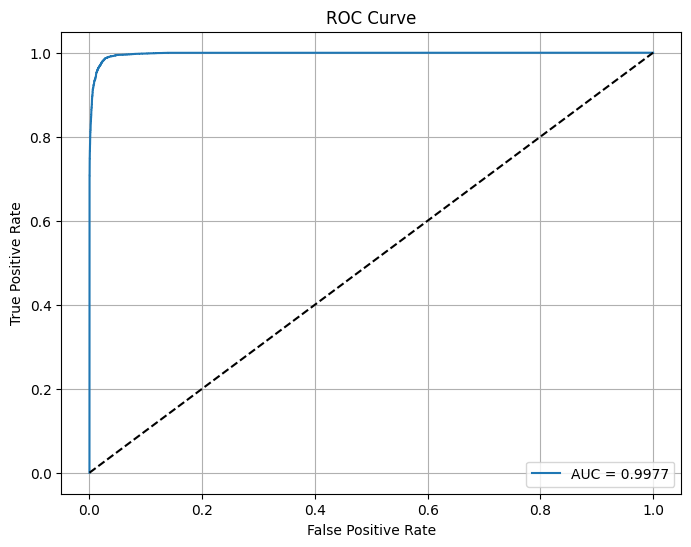

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(xgb_fpr, xgb_tpr, label=f"AUC = {xgb_auc:.4f}")  # 4 decimal places
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

Confusion Matrix:
 [[10687   265]
 [  182  9220]]


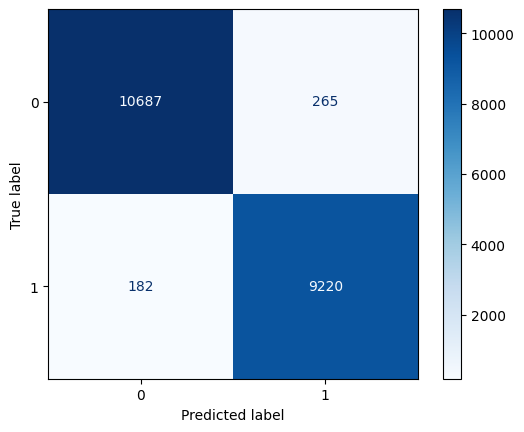

In [32]:
cm = confusion_matrix(y_test, y_pred_xgb)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

## LinearSVC

In [34]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

In [35]:
linear_svc_l1 = LinearSVC(penalty='l1', dual=False, C=0.1, max_iter=100000, random_state=42)

linear_svc_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selector', SelectFromModel(linear_svc_l1)),
    ('final_model', LinearSVC(penalty='l2', dual=True, C=1.0, max_iter=100000, random_state=42))  # Final model after selection
])

# Fit the pipeline
linear_svc_pipeline.fit(X_train, y_train)

print("Done training, predicting..")
y_pred_svc = linear_svc_pipeline.predict(X_test)
y_prob_svc = linear_svc_pipeline.decision_function(X_test)

svc_fpr, svc_tpr, _ = roc_curve(y_test, y_prob_svc)
svc_auc = roc_auc_score(y_test, y_prob_svc)

print(classification_report(y_test, y_pred_svc))
print("AUC:", svc_auc)

Done training, predicting..
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     10952
           1       0.95      0.86      0.91      9402

    accuracy                           0.92     20354
   macro avg       0.92      0.91      0.92     20354
weighted avg       0.92      0.92      0.92     20354

AUC: 0.9801951922170019


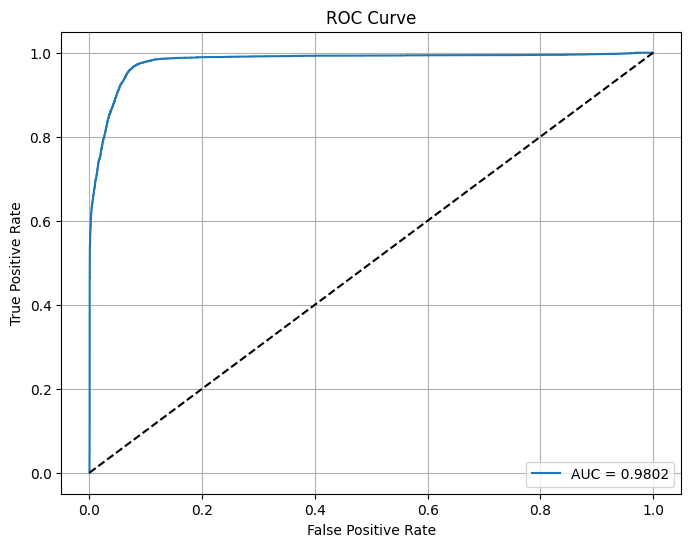

In [36]:
plt.figure(figsize=(8, 6))
plt.plot(svc_fpr, svc_tpr, label=f"AUC = {svc_auc:.4f}")  # 4 decimal places
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

Confusion Matrix:
 [[10527   425]
 [ 1271  8131]]


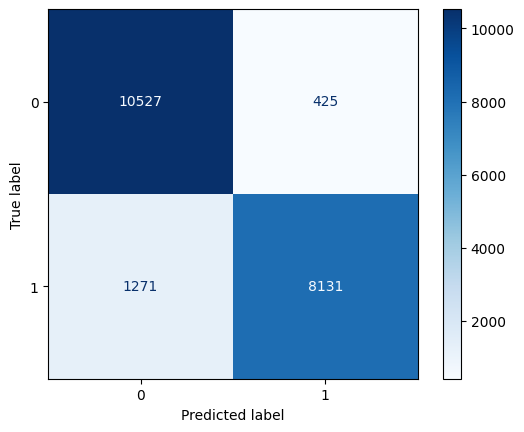

In [37]:
cm = confusion_matrix(y_test, y_pred_svc)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

## Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression

In [42]:
logistic_reg_pipeline = Pipeline(
    steps=[('preprocessor', preprocessor), 
      ('model', LogisticRegressionCV(penalty='l1'
     ,solver='saga'
     ,Cs=np.logspace(-4, 4, 20)  
     ,cv=5
     ,random_state=42
     ,max_iter=100000
     ,n_jobs=-1 ))
])

print("training")
# Fit the pipeline
logistic_reg_pipeline.fit(X_train, y_train)

print("Done training, predicting..")
y_pred_lr = logistic_reg_pipeline.predict(X_test)
y_prob_lr = logistic_reg_pipeline.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print(classification_report(y_test, y_pred_lr))
print("AUC:", lr_auc)

training
Done training, predicting..
              precision    recall  f1-score   support

           0       0.92      0.96      0.94     10952
           1       0.95      0.90      0.93      9402

    accuracy                           0.93     20354
   macro avg       0.94      0.93      0.93     20354
weighted avg       0.93      0.93      0.93     20354

AUC: 0.9810347465430556


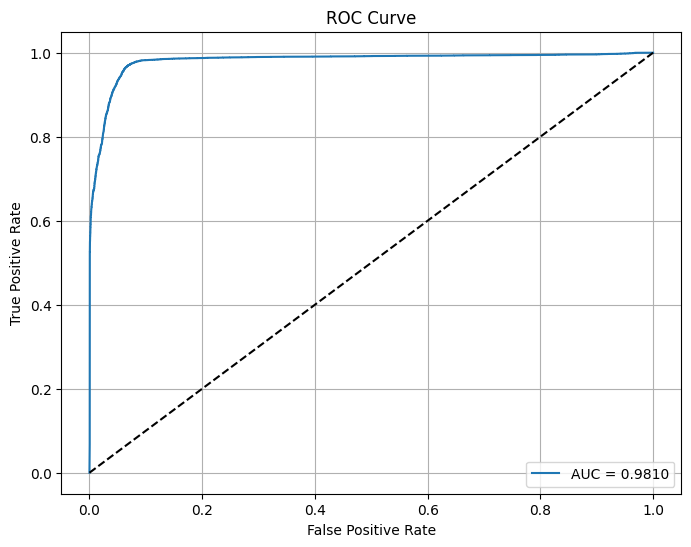

In [43]:
plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"AUC = {lr_auc:.4f}")  # 4 decimal places
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)

Confusion Matrix:
 [[10515   437]
 [  921  8481]]


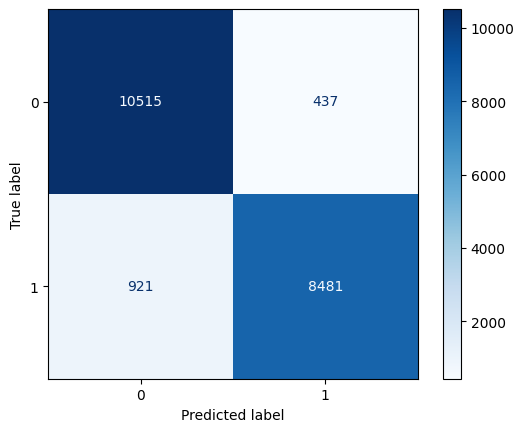

In [44]:
cm = confusion_matrix(y_test, y_pred_lr)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)

# Visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')

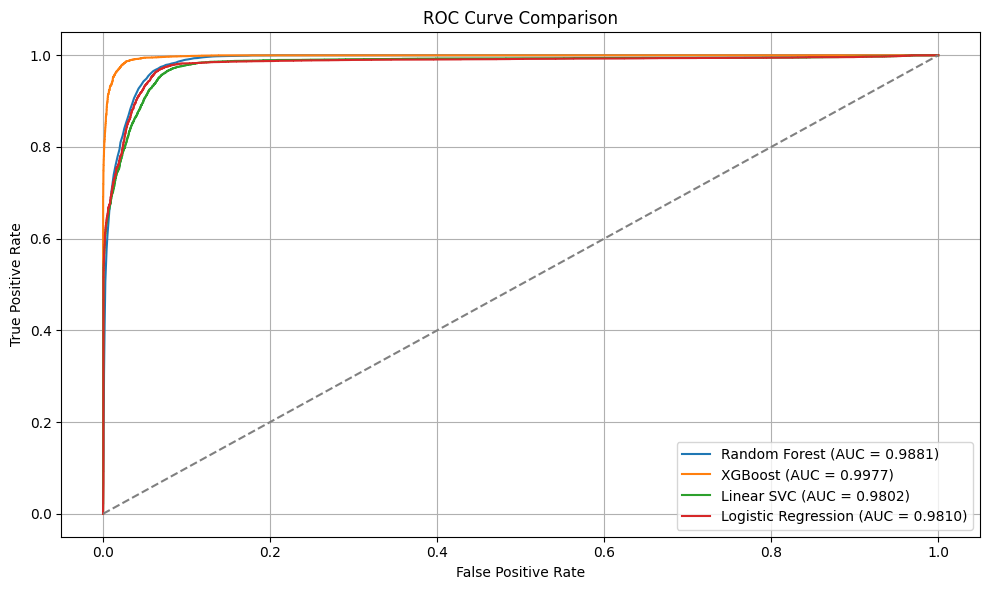

In [46]:
rf_fpr, rf_tpr, _ = roc_curve(y_test, y_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_prob_xgb)
svc_fpr, svc_tpr, _ = roc_curve(y_test, y_prob_svc)
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob_lr)


plt.figure(figsize=(10, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot(svc_fpr, svc_tpr, label=f'Linear SVC (AUC = {svc_auc:.4f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()